In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv("./datasets/users.csv")

In [3]:
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0
...,...,...,...,...,...
94,15786993,Female,45,83000,0
95,15709441,Female,35,44000,0
96,15710257,Female,4,25000,0
97,15582492,Male,5,123000,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          99 non-null     int64 
 1   Gender           99 non-null     object
 2   Age              99 non-null     int64 
 3   EstimatedSalary  99 non-null     int64 
 4   Purchased        99 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [5]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [6]:
data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [7]:
data['Purchased'].unique()

array([0, 1])

In [8]:
X = data.columns.drop('Purchased')
y = data['Purchased']

In [ ]:
data_encoded = pd.get_dummies(data[X]).astype(int)

In [10]:
data_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data_encoded,y, test_size=0.2)

In [12]:
data_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [13]:
X_train.shape

(79, 5)

In [14]:
X_test.shape

(20, 5)

In [15]:
y_train.shape

(79,)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="gini", random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [17]:
model.score(X_train, y_train)

1.0

In [18]:
model.score(X_test,y_test)

0.75

In [19]:
X_train.shape

(79, 5)

In [20]:
X_test.shape

(20, 5)

In [21]:
y_train.shape

(79,)

In [22]:
y_test.shape

(20,)

In [23]:
# Predicting target values using the model built on training data
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

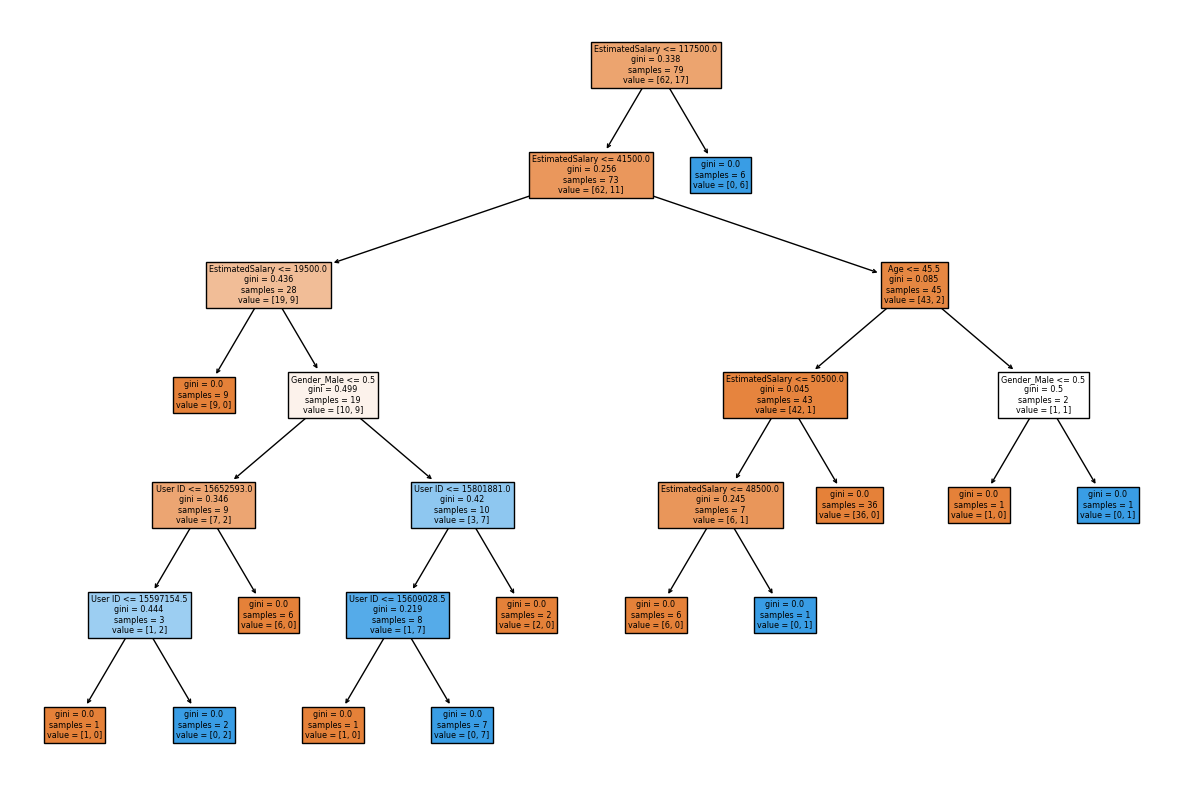

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=data_encoded.columns, filled=True)
plt.show()

In [25]:
# Getting the accuracy on train data
train_accuracy = model.score(X_train,y_train)
print("Accuracy of the model on train data = ",train_accuracy)
# Getting the accuracy on test data
test_accuracy = model.score(X_test,y_test)
print("Accuracy of the model on test data = ",test_accuracy)

Accuracy of the model on train data =  1.0
Accuracy of the model on test data =  0.75


##### Gaussian Naive Bayes Classifier Iris

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn Imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)



In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
# divide data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
X_train.shape, X_test.shape

((120, 4), (30, 4))

In [39]:
y_train.shape, y_test.shape

((120,), (30,))

In [43]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [44]:
# Prediction
y_pred = model.predict(X_test)

In [46]:
# Evaluation 
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  1.0


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [48]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Text(50.722222222222214, 0.5, 'Actual')

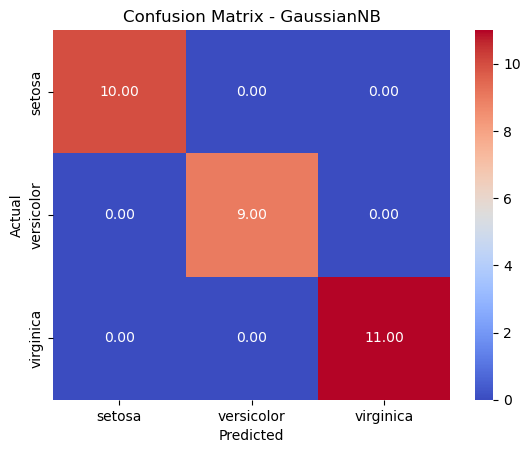

In [56]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.2f', xticklabels=iris.target_names, yticklabels=iris.target_names, cmap='coolwarm')
plt.title("Confusion Matrix - GaussianNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")